In [1]:

from tqdm import tqdm
import os
from tbparse import SummaryReader
import pandas as pd



# Overview over the first experiment

Train:
- 70% of participants as train
- 30% as test

different combination tested:
- Architecture: unet, unet++, deeplabv3, fpn, pspnet, segformer
- Encoder: resnet34, resnet50, efficientnet-b0, efficientnet-b1, efficientnet-b2, efficientnet-b3 
- Input normalization: None, min-max, z-score

In [2]:
from utils import read_runs
results_df = read_runs("runs", "Segmentationmodels_full_supervised_training")
results_df.head()

Summary file results/Segmentationmodels_full_supervised_training_summary.csv already exists. Loading it.


,arch,augment,batch_size,encoder_name,gpu,hflip_p,lr,max_rotate_deg,normalize,num_epochs,num_workers,train_portion,weight_decay,train_loss_at_best_val,val_dice,val_iou,val_loss
0,deeplabv3+,1.0,16.0,efficientnet-b0,1.0,0.5,0.001,0.0,none,20.0,4.0,0.7,0.0001,0.013829,0.980201,0.961566,0.017297
1,deeplabv3+,1.0,16.0,efficientnet-b0,1.0,0.5,0.001,0.0,minmax,20.0,4.0,0.7,0.0001,0.014083,0.980974,0.963021,0.016860
2,deeplabv3+,1.0,16.0,efficientnet-b0,1.0,0.5,0.001,0.0,zscore,20.0,4.0,0.7,0.0001,0.015089,0.979529,0.960246,0.017916
3,deeplabv3+,1.0,16.0,efficientnet-b1,1.0,0.5,0.001,0.0,none,20.0,4.0,0.7,0.0001,0.014826,0.981209,0.963635,0.017127
4,deeplabv3+,1.0,16.0,efficientnet-b1,1.0,0.5,0.001,0.0,minmax,20.0,4.0,0.7,0.0001,0.014141,0.980707,0.962818,0.017709


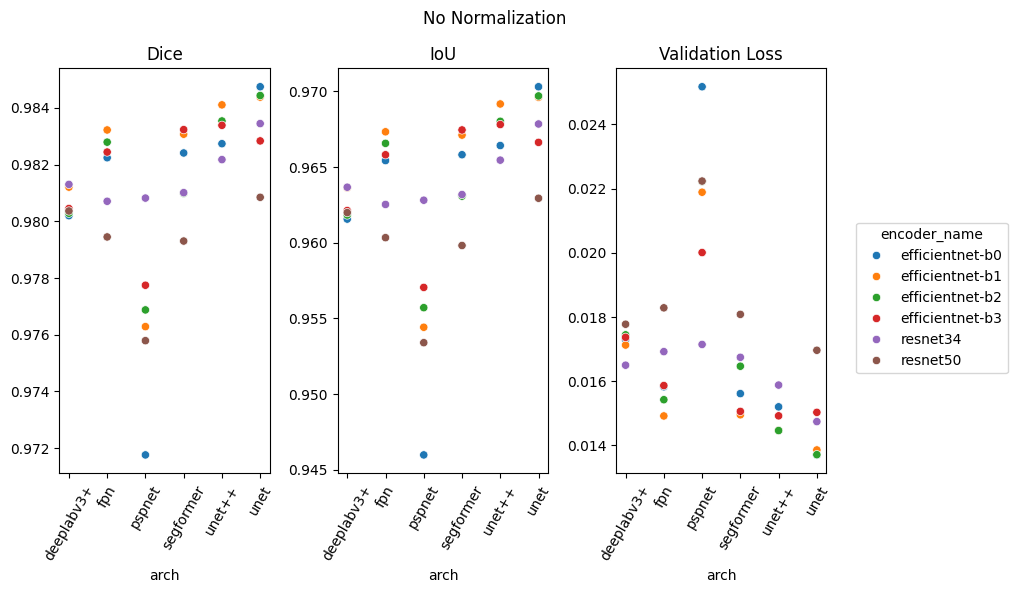

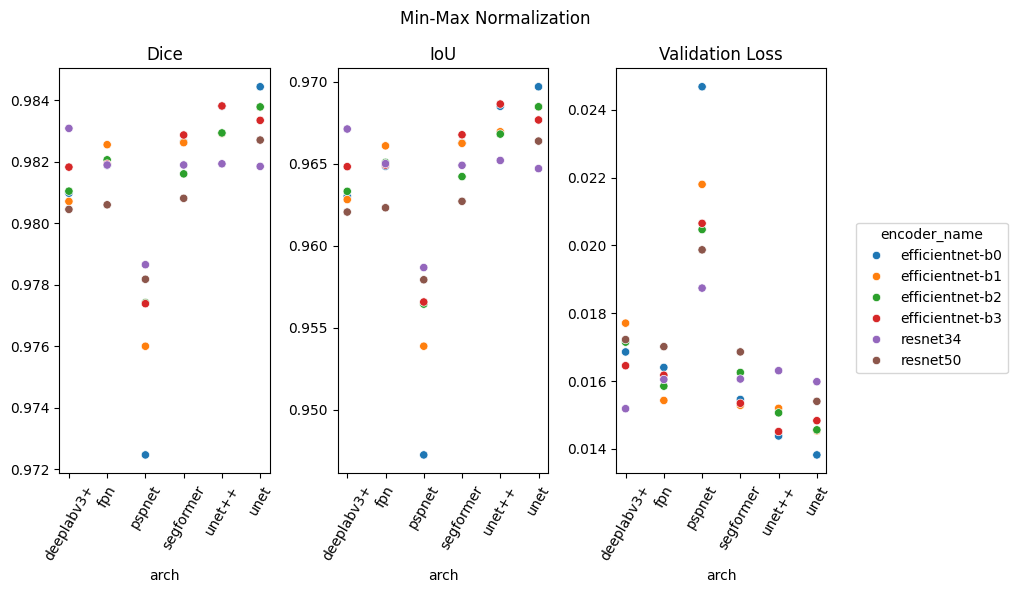

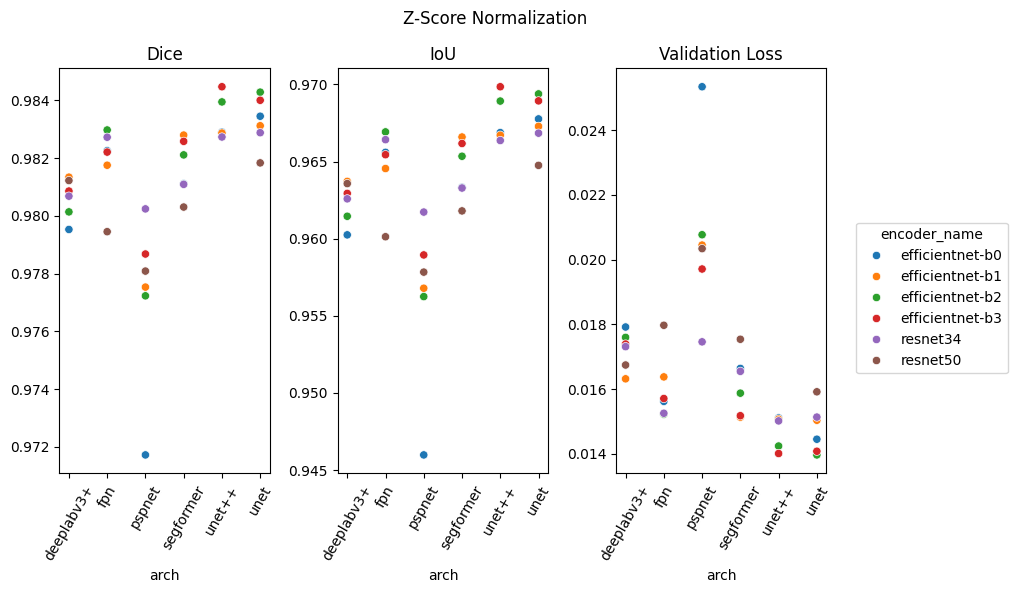

In [3]:
# plot scatter: x-axes architecture, y-axes val_dice, color by encoder_name
import matplotlib.pyplot as plt
import seaborn as sns

def plot_results(data, x, hue, title):
    fig, axs = plt.subplots(1, 3, figsize=(10, 6))

    sns.scatterplot(data=data, x=x, y="val_dice", hue=hue, ax=axs[0])
    axs[0].set_title("Dice")
    axs[0].set_ylabel("")
    sns.scatterplot(data=data, x=x, y="val_iou", hue=hue, ax=axs[1], legend=False)
    axs[1].set_title("IoU")
    axs[1].set_ylabel("")
    sns.scatterplot(data=data, x=x, y="val_loss", hue=hue, ax=axs[2], legend=False)
    axs[2].set_title("Validation Loss")
    axs[2].set_ylabel("")

    handles, labels = axs[0].get_legend_handles_labels()
    if axs[0].legend_ is not None:
        axs[0].legend_.remove()
    fig.legend(handles, labels, title=hue, loc="center right", bbox_to_anchor=(1.02, 0.5))

    for ax in axs:
        ax.tick_params(axis="x", labelrotation=60)

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

res_none_norm = results_df[results_df["normalize"] == "none"]
plot_results(res_none_norm, x="arch", hue="encoder_name", title="No Normalization")
res_minmax_norm = results_df[results_df["normalize"] == "minmax"]
plot_results(res_minmax_norm, x="arch", hue="encoder_name", title="Min-Max Normalization") 
res_zscore_norm = results_df[results_df["normalize"] == "zscore"]
plot_results(res_zscore_norm, x="arch", hue="encoder_name", title="Z-Score Normalization")

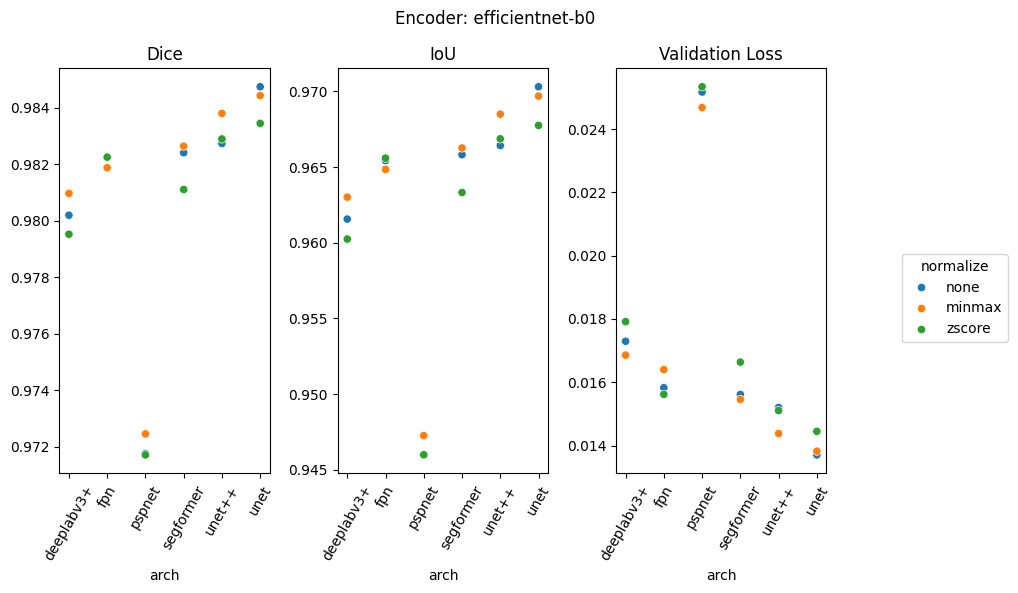

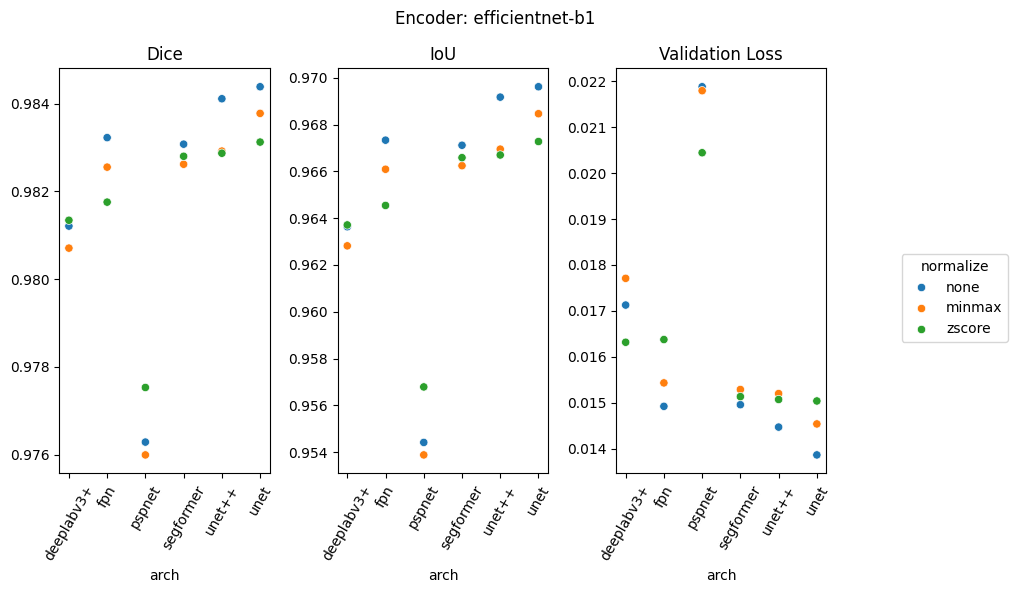

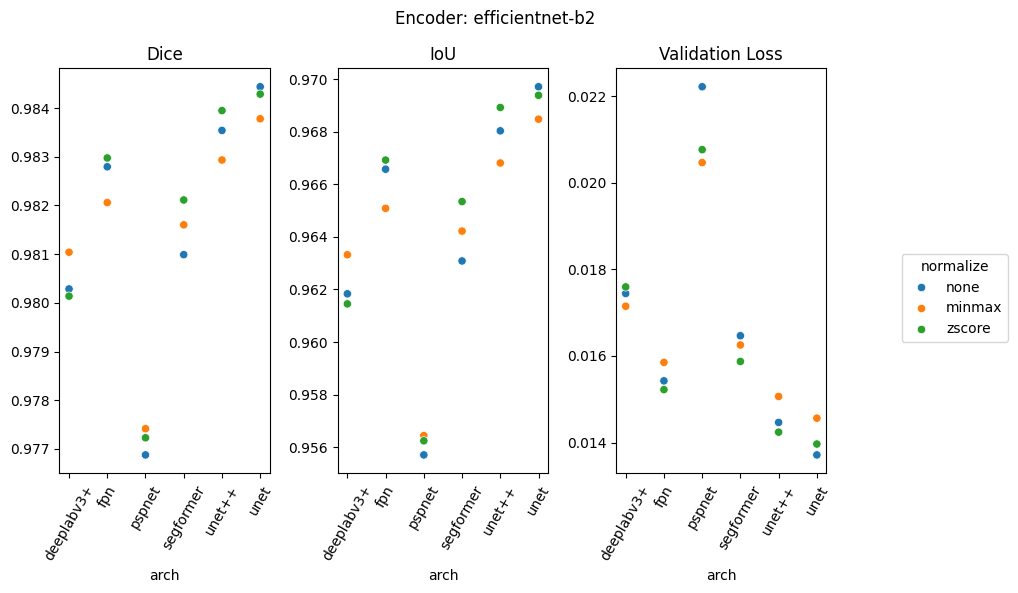

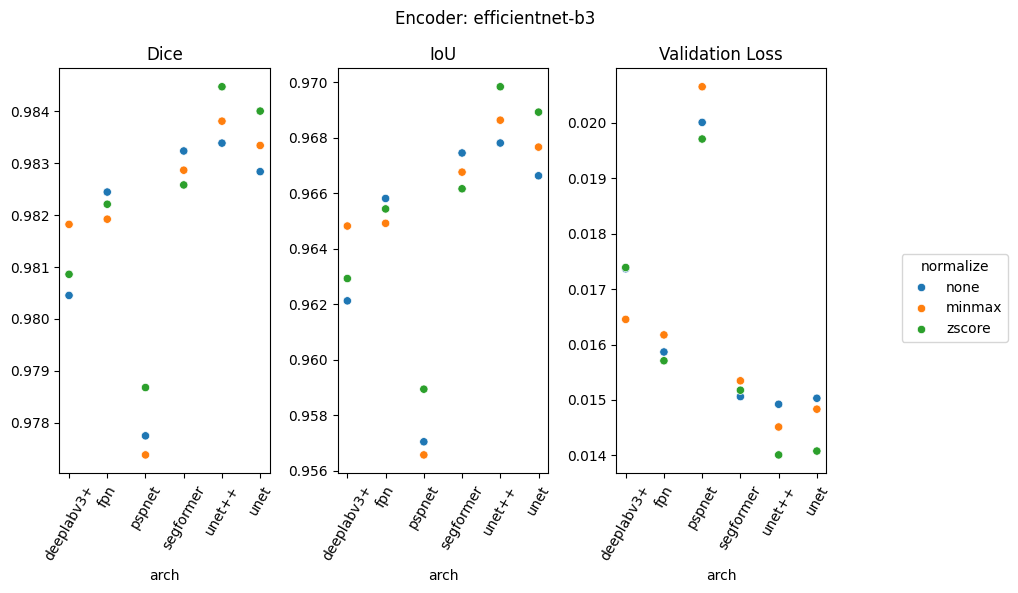

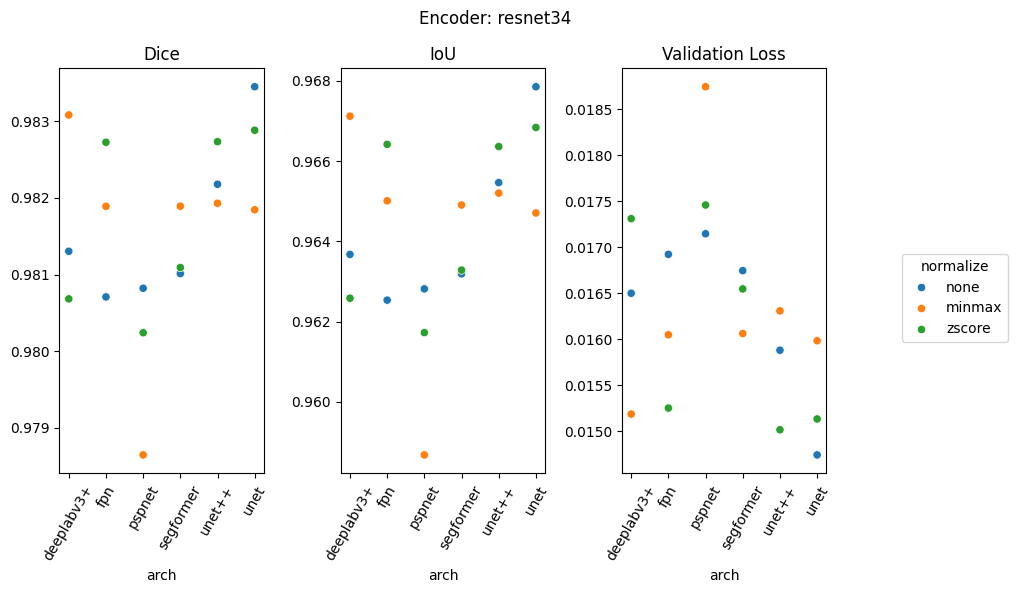

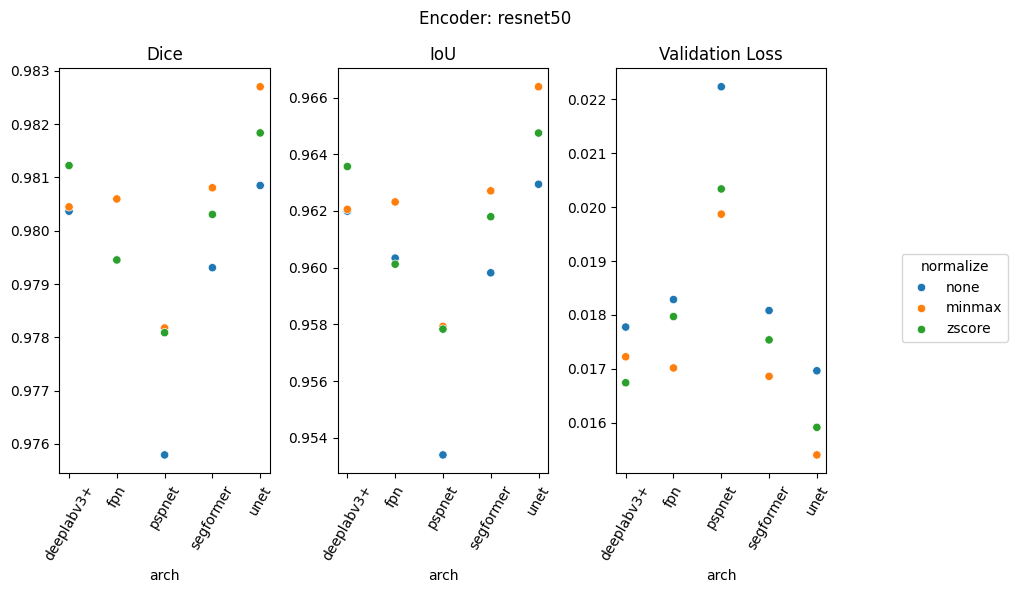

In [4]:
encoder = results_df["encoder_name"].unique()
for enc in encoder:
    res_enc = results_df[results_df["encoder_name"] == enc]
    plot_results(res_enc, x="arch", hue="normalize", title=f"Encoder: {enc}")

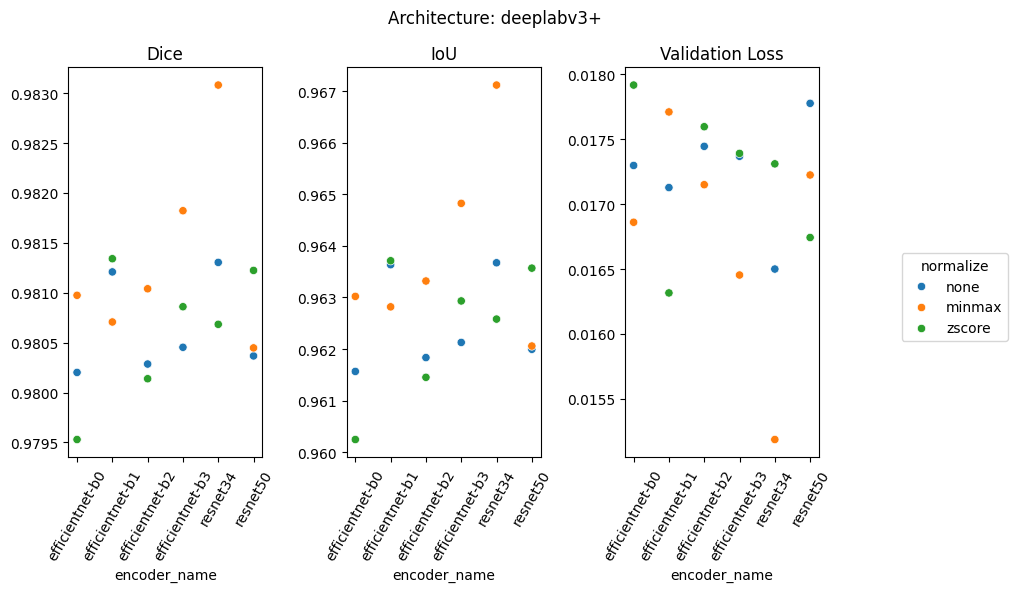

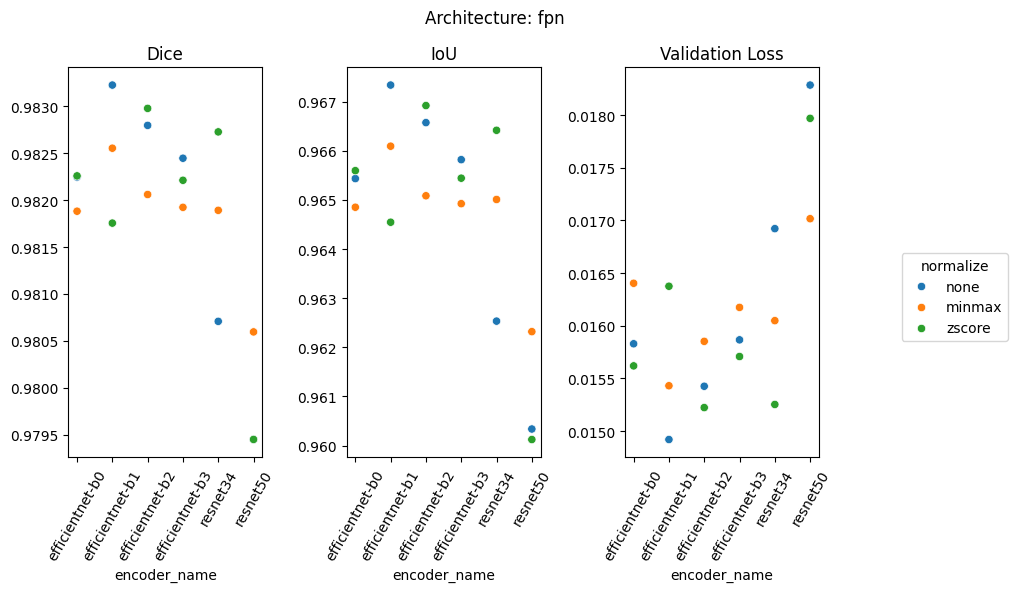

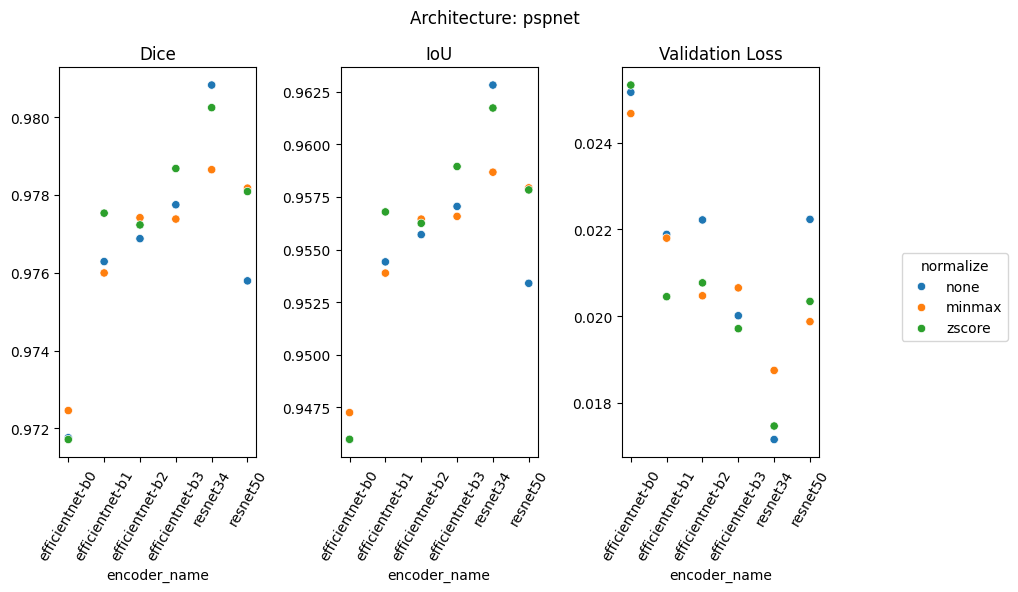

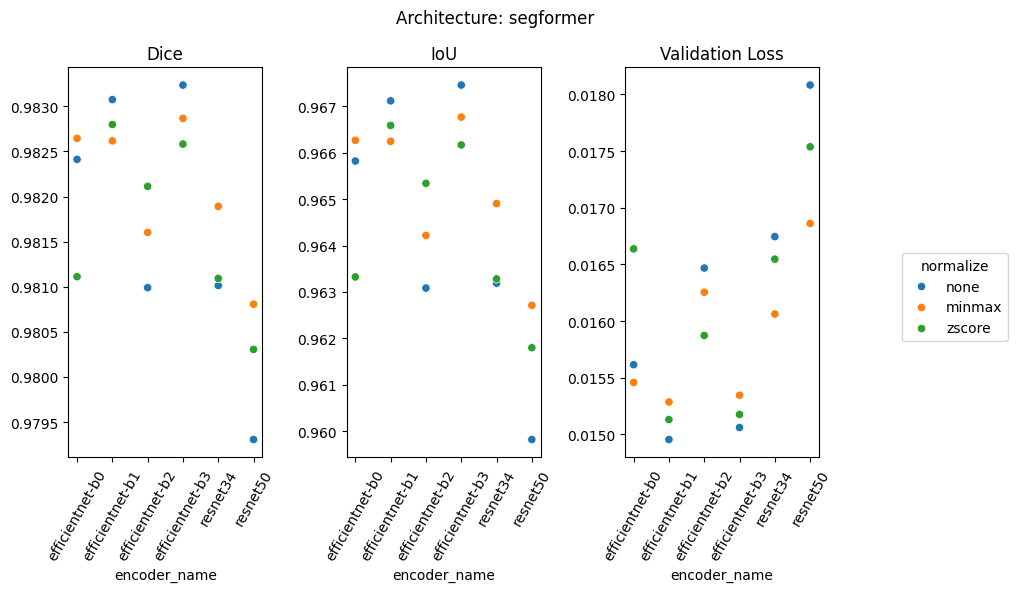

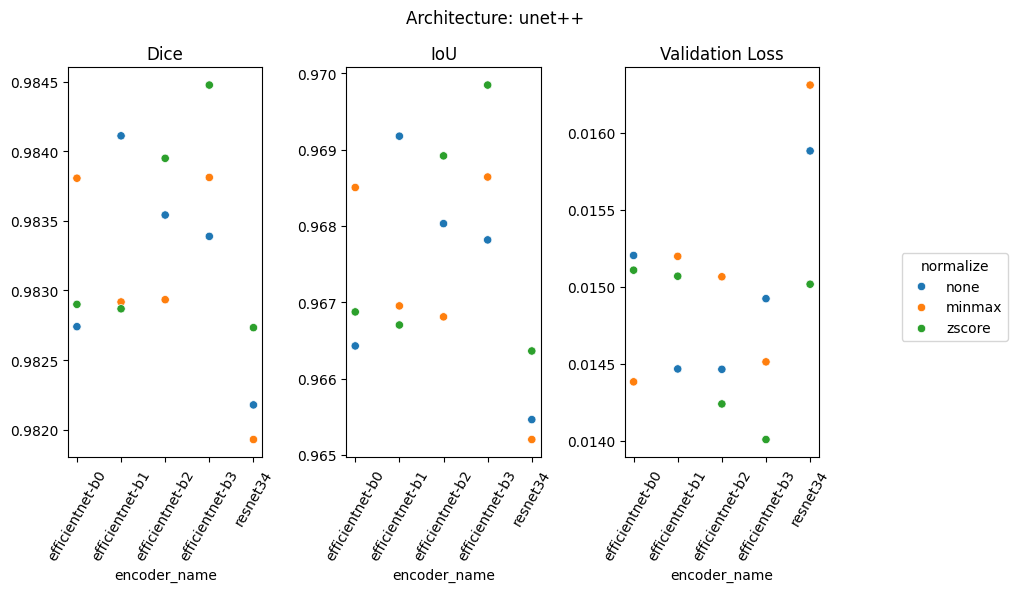

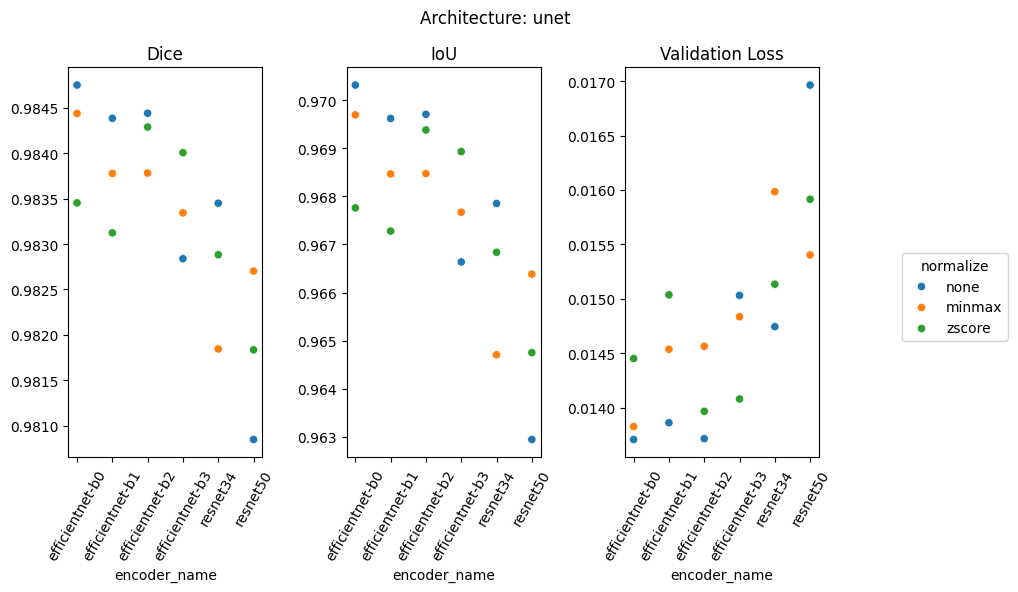

In [5]:
archs = results_df["arch"].unique()
for arch in archs:
    res_arch = results_df[results_df["arch"] == arch]
    plot_results(res_arch, x="encoder_name", hue="normalize", title=f"Architecture: {arch}")

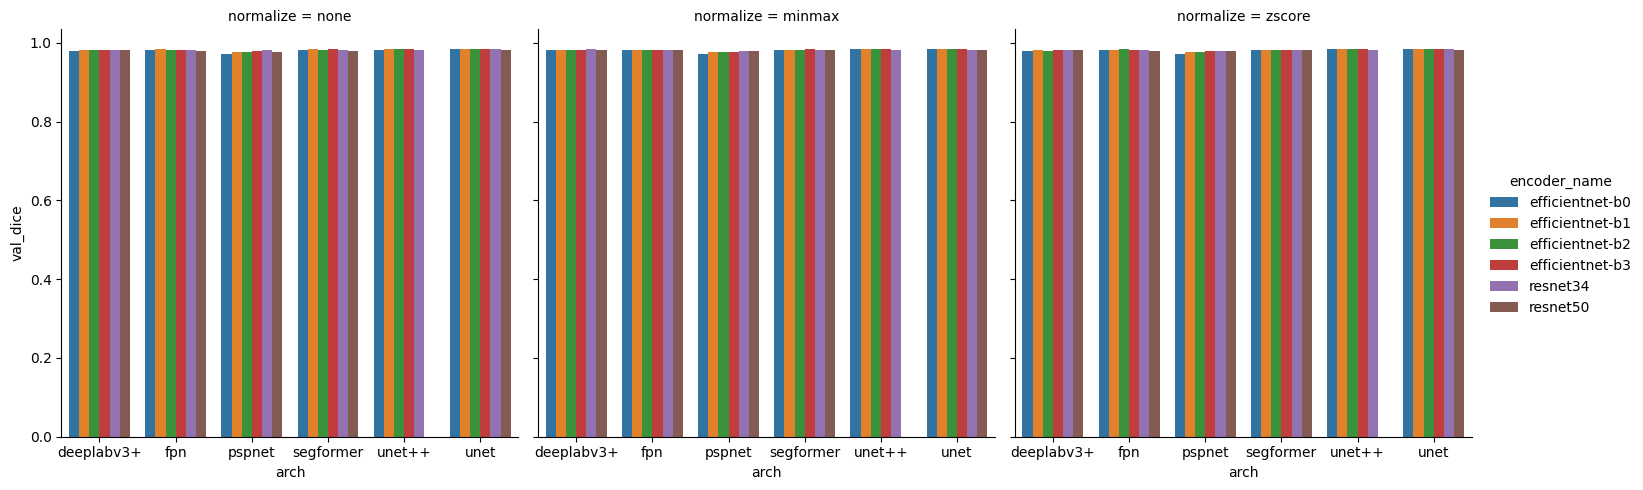

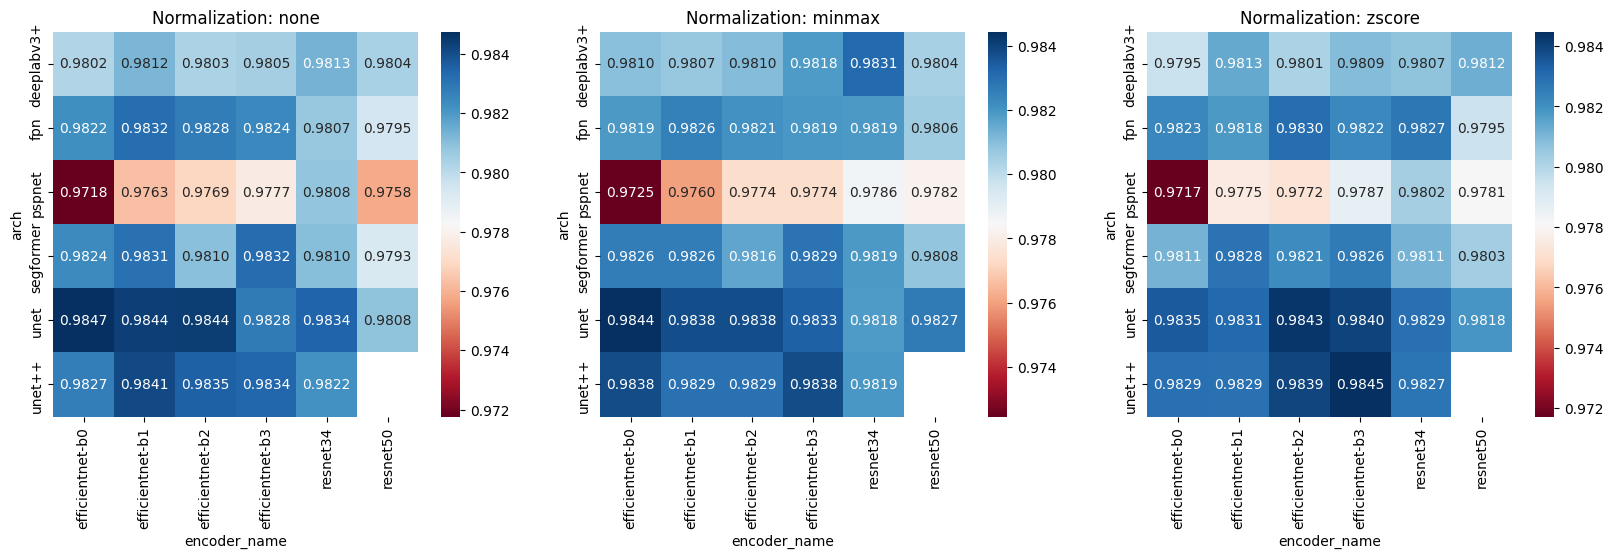

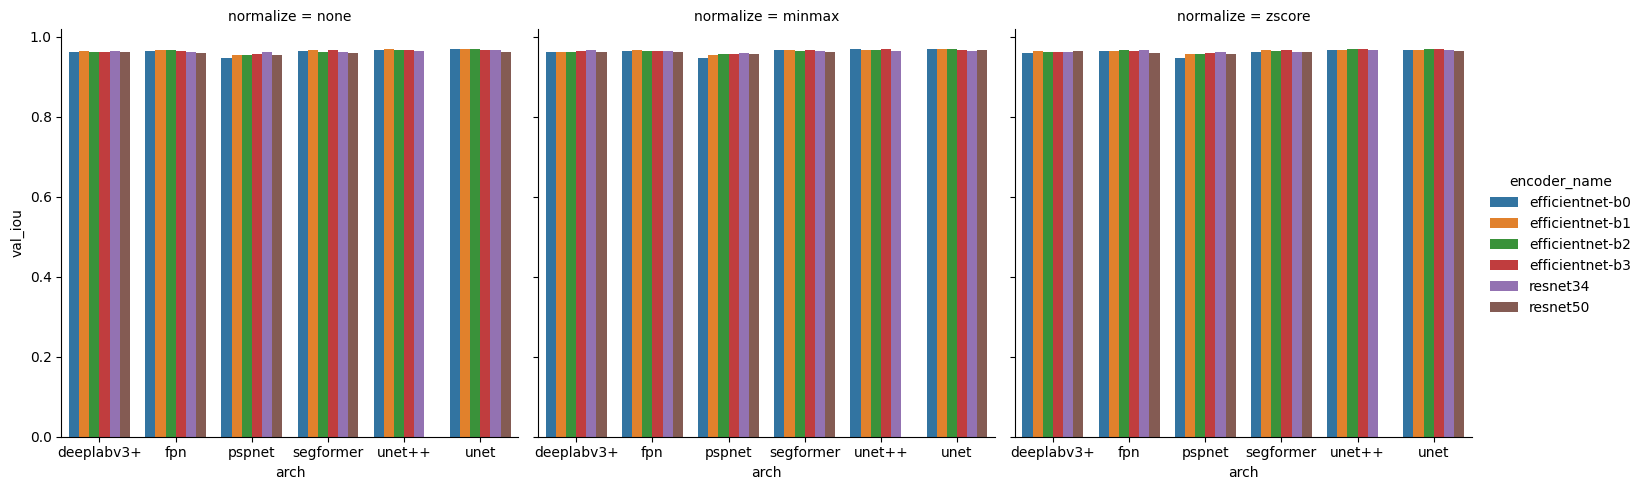

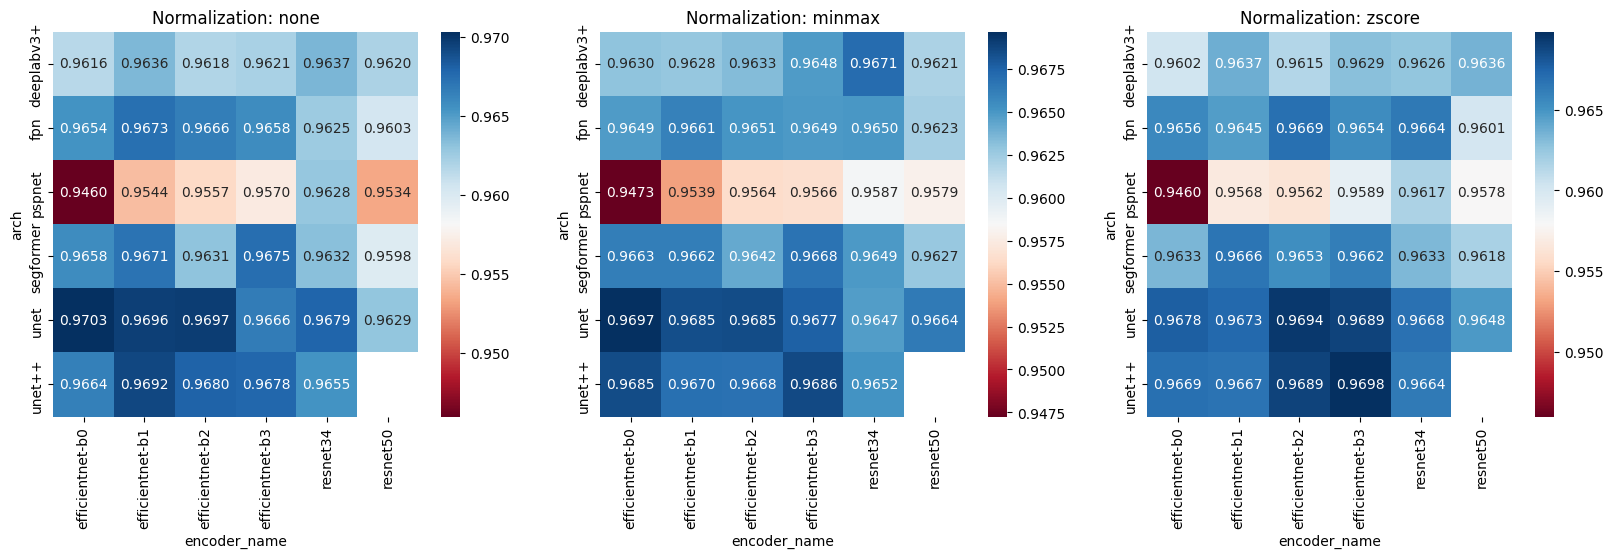

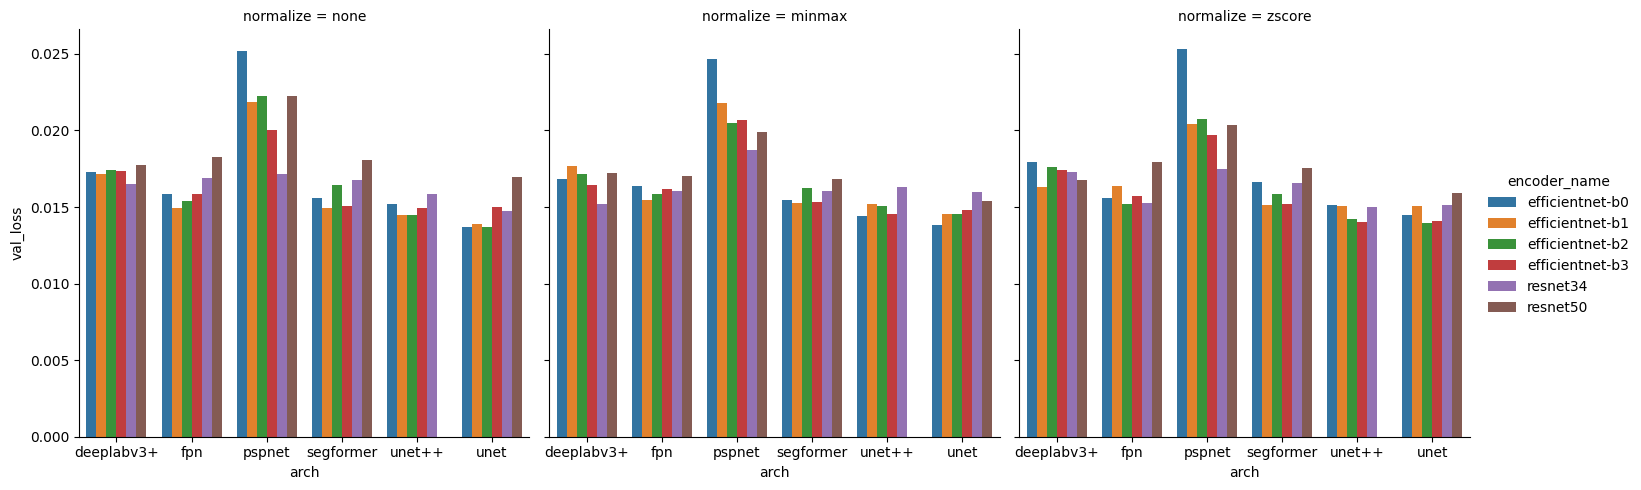

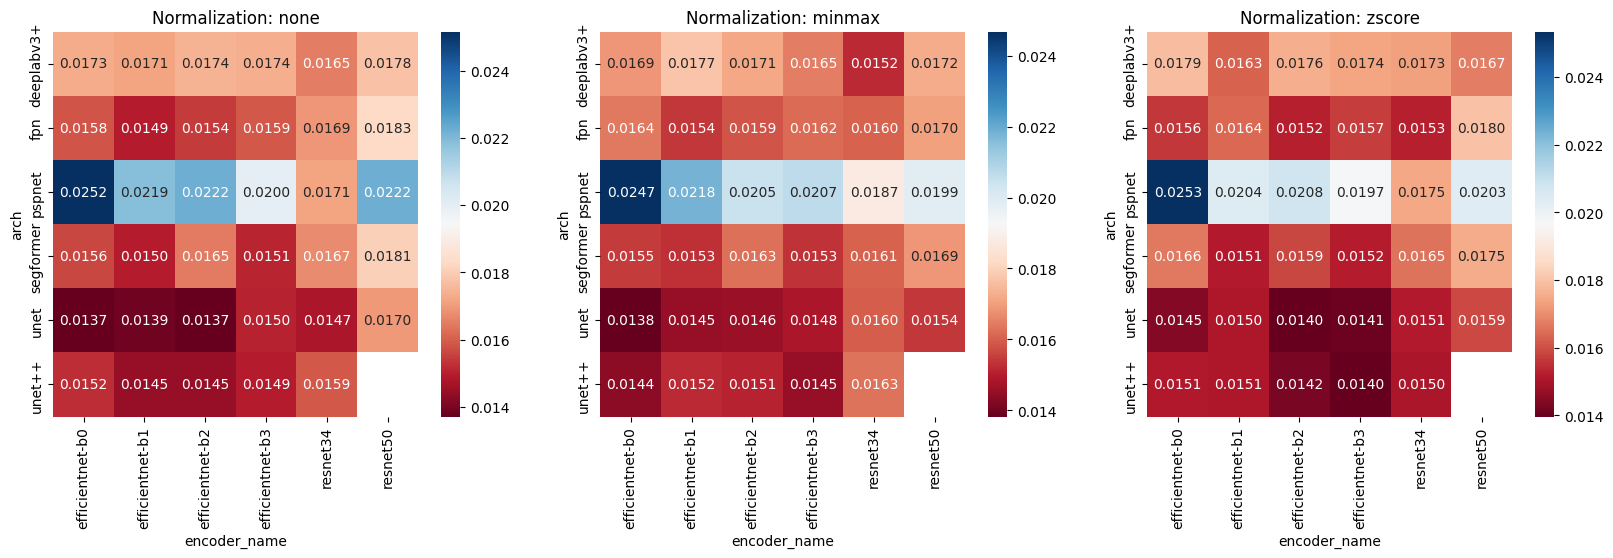

In [6]:
for metric in ["val_dice", "val_iou", "val_loss"]:
    sns.catplot(
        data = results_df,
        x = "arch",
        y = metric,
        hue = "encoder_name",
        col = "normalize",
        kind="bar"
    )
    plt.show()

    fig, axs = plt.subplots(1, 3, figsize=(20, 5))
    for i, norm in enumerate(results_df["normalize"].unique()):
        pivot = results_df[results_df["normalize"] == norm].pivot_table(index="arch", columns="encoder_name", values=metric)
        sns.heatmap(pivot, annot=True, fmt=".4f", cmap="RdBu",ax=axs[i])
        axs[i].set_title(f"Normalization: {norm}")

# Results second experiment

Encoder pretraining:
- self supervised
- other oct dataset without lables
- zscore normalization 

Arch training:
- 5% of the participants are training
- 95% are testing
- Compare pretrained vs from scratch


In [2]:
from utils import read_runs
results_df = read_runs("runs", "scratchVSpretrained")
results_df["pretrained"] = ~results_df["encoder_weights_path"].isna()
results_df.sort_values("val_dice",ascending=False).head()


Summary file results/scratchVSpretrained_summary.csv already exists. Loading it.


,arch,augment,batch_size,encoder_name,gpu,hflip_p,lr,max_rotate_deg,normalize,num_epochs,num_freeze_encoder_epochs,num_workers,train_portion,weight_decay,train_loss_at_best_val,val_dice,val_iou,val_loss,encoder_weights_path,pretrained
212,unet,1.0,16.0,vgg11_bn,1.0,0.5,0.001,0.0,zscore,20.0,0.0,0.0,0.05,0.0001,0.038677,0.949458,0.906485,0.045040,NaN,False
187,unet,1.0,16.0,efficientnet-b3,1.0,0.5,0.001,0.0,zscore,20.0,10.0,0.0,0.05,0.0001,0.036895,0.946830,0.902161,0.049844,trained_models/encoder_models/pretrained_effic...,True
135,segformer,1.0,16.0,efficientnet-b1,1.0,0.5,0.001,0.0,zscore,20.0,10.0,0.0,0.05,0.0001,0.036014,0.944459,0.898207,0.048805,trained_models/encoder_models/pretrained_effic...,True
216,unet,1.0,16.0,vgg13_bn,1.0,0.5,0.001,0.0,zscore,20.0,0.0,0.0,0.05,0.0001,0.038583,0.942435,0.898712,0.053302,NaN,False
208,unet,1.0,16.0,resnet34,1.0,0.5,0.001,0.0,zscore,20.0,0.0,0.0,0.05,0.0001,0.045082,0.941554,0.896913,0.055725,NaN,False


In [3]:
df_pivot = results_df.pivot_table(
    index=["arch", "encoder_name", "normalize"],
    values=["val_dice", "val_iou", "val_loss"],
    columns="pretrained"
).reset_index()
df_pivot["delta_dice"] = df_pivot[("val_dice", True)] - df_pivot[("val_dice", False)]
df_pivot["delta_iou"] = df_pivot[("val_iou", True)] - df_pivot[("val_iou", False)]
df_pivot["delta_loss"] = df_pivot[("val_loss", False)] - df_pivot[("val_loss", True)] # because lower loss is better, so we subtract pretrained from scratch to get a positive delta if pretrained is better 
df_pivot.head()

arch     encoder_name normalize      val_dice            \
pretrained                                                False      True   
0           deeplabv3+            dpn68    zscore  9.109428e-01  0.919199   
1           deeplabv3+  efficientnet-b0    zscore  4.403747e-12  0.881573   
2           deeplabv3+  efficientnet-b1    zscore  4.403747e-12  0.917448   
3           deeplabv3+  efficientnet-b2    zscore  4.403747e-12  0.923751   
4           deeplabv3+  efficientnet-b3    zscore  4.403747e-12  0.910041   

                 val_iou            val_loss           delta_dice delta_iou  \
pretrained         False      True     False      True                        
0           8.505639e-01  0.861124  0.078700  0.073944   0.008256  0.010560   
1           4.403747e-12  0.804741  0.635246  0.100794   0.881573  0.804741   
2           4.403747e-12  0.856323  0.647531  0.073978   0.917448  0.856323   
3           4.403747e-12  0.865500  0.595529  0.066902   0.923751  0.865500   
4           4.403747e-12  0.844908  0.644059  0.080247   0.910041  0.844908   

           delta_loss  
pretrained             
0            0.004756  
1            0.534452  
2            0.573553  
3            0.528626  
4            0.563812

In [8]:
df_pivot

,arch,encoder_name,normalize,val_dice_False,val_dice_True,val_iou_False,val_iou_True,val_loss_False,val_loss_True,delta_dice,delta_iou,delta_loss
0,deeplabv3+,dpn68,zscore,9.109428e-01,0.919199,8.505639e-01,0.861124,0.078700,0.073944,0.008256,0.010560,0.004756
1,deeplabv3+,efficientnet-b0,zscore,4.403747e-12,0.881573,4.403747e-12,0.804741,0.635246,0.100794,0.881573,0.804741,0.534452
2,deeplabv3+,efficientnet-b1,zscore,4.403747e-12,0.917448,4.403747e-12,0.856323,0.647531,0.073978,0.917448,0.856323,0.573553
3,deeplabv3+,efficientnet-b2,zscore,4.403747e-12,0.923751,4.403747e-12,0.865500,0.595529,0.066902,0.923751,0.865500,0.528626
4,deeplabv3+,efficientnet-b3,zscore,4.403747e-12,0.910041,4.403747e-12,0.844908,0.644059,0.080247,0.910041,0.844908,0.563812
...,...,...,...,...,...,...,...,...,...,...,...,...
107,unet,vgg13,zscore,9.145974e-01,0.935593,8.560241e-01,0.884959,0.075203,0.057376,0.020996,0.028935,0.017827
108,unet,vgg13_bn,zscore,9.424350e-01,0.935288,8.987123e-01,0.886405,0.053302,0.060624,-0.007147,-0.012308,-0.007322
109,unet,vgg16,zscore,8.985370e-01,0.940802,8.242756e-01,0.892085,0.087729,0.055174,0.042265,0.067810,0.032555
110,unet,vgg16_bn,zscore,9.408932e-01,0.940751,8.936357e-01,0.893291,0.055986,0.055566,-0.000143,-0.000345,0.000420


In [10]:
", ".join(df_pivot.encoder_name.unique())

'dpn68, efficientnet-b0, efficientnet-b1, efficientnet-b2, efficientnet-b3, efficientnet-b4, mit_b0, mit_b1, mobilenet_v2, mobileone_s0, mobileone_s1, mobileone_s2, mobileone_s3, mobileone_s4, resnet18, resnet34, densenet121, vgg11, vgg11_bn, vgg13, vgg13_bn, vgg16, vgg16_bn, vgg19_bn'

[]

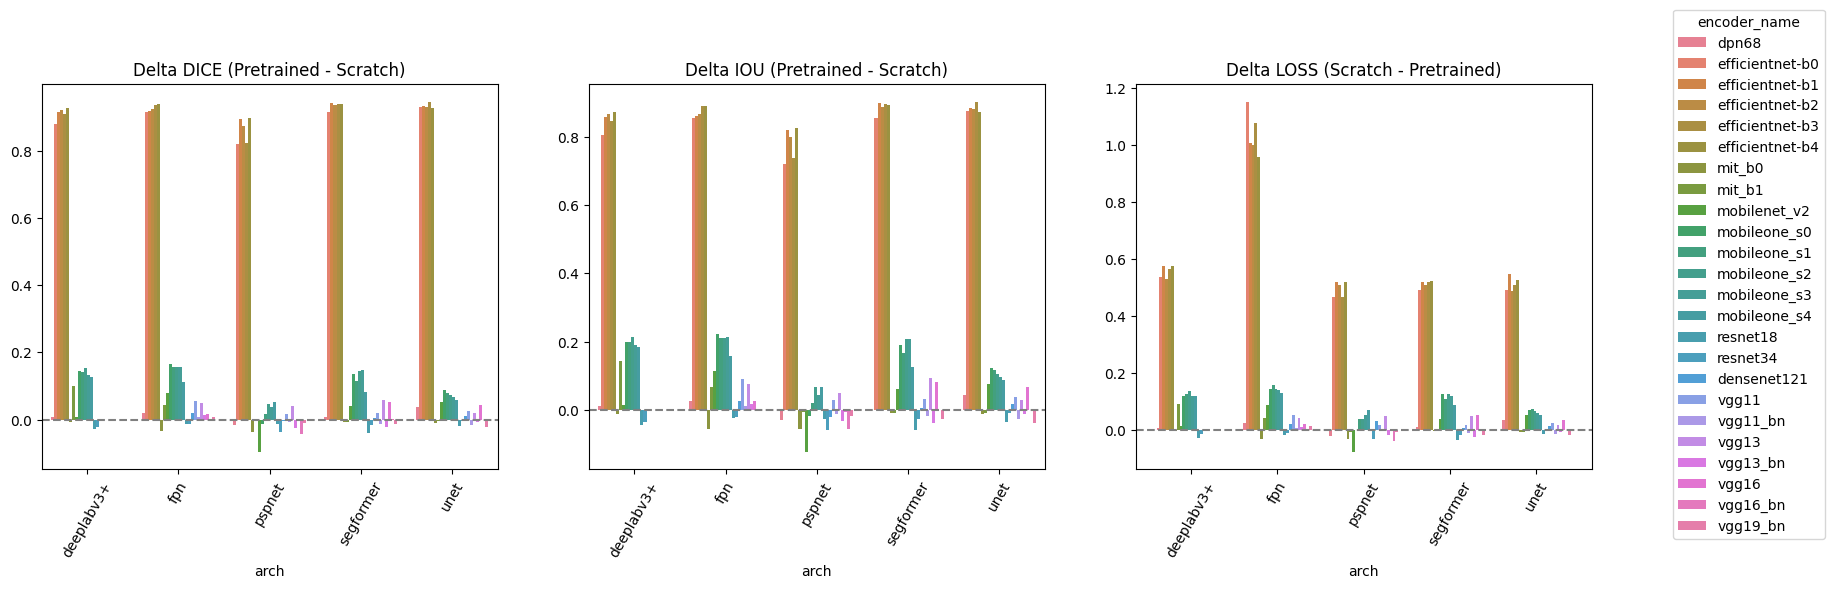

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
for i, metric in enumerate(["delta_dice", "delta_iou", "delta_loss"]):
    sns.barplot(data=df_pivot, x="arch", y=metric, hue="encoder_name", ax=axs[i], legend=i==0)
    axs[i].set_title(f"Delta {metric.split('_')[1].upper()} ({"Pretrained - Scratch" if metric != "delta_loss" else "Scratch - Pretrained"})")
    axs[i].set_ylabel("")
    axs[i].tick_params(axis="x", labelrotation=60)
    axs[i].axhline(0, color="gray", linestyle="--")

handles, labels = axs[0].get_legend_handles_labels()
if axs[0].legend_ is not None:
    axs[0].legend_.remove()
fig.legend(handles, labels, title="encoder_name", loc="center right", bbox_to_anchor=(1.02, 0.5))
plt.plot()

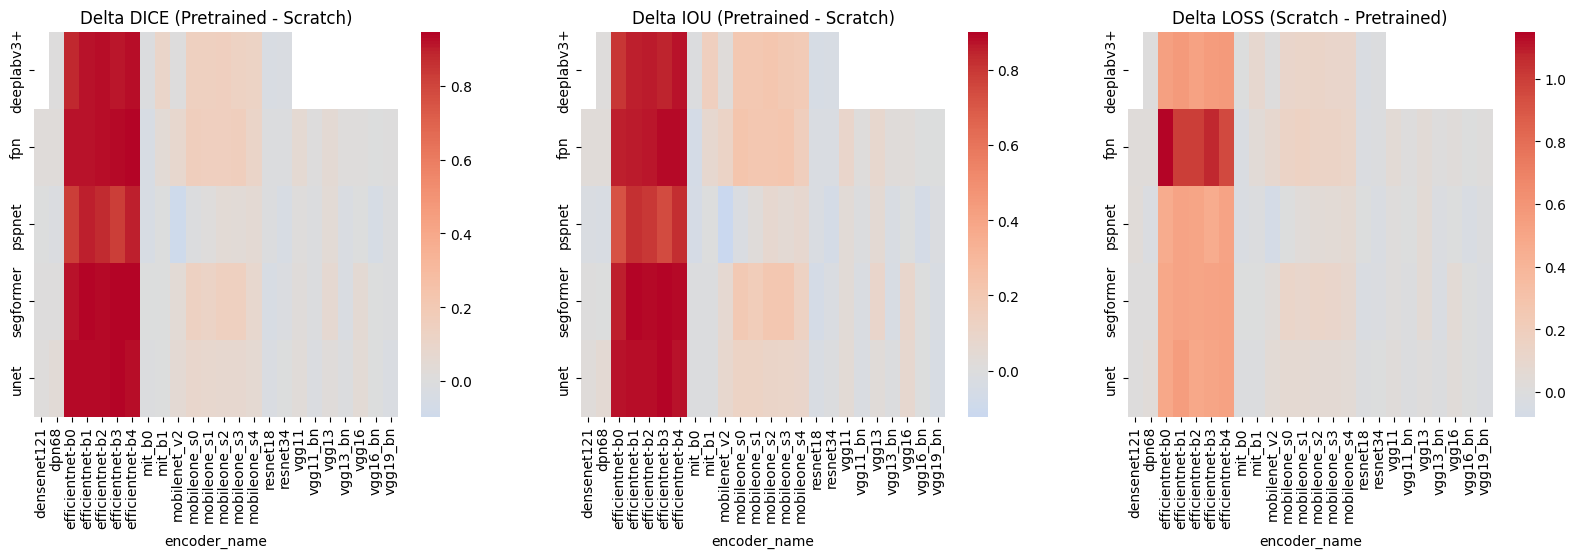

In [7]:
df_pivot.columns = [
    "_".join([str(c) for c in col if c != ""]).strip()
    if isinstance(col, tuple)
    else col
    for col in df_pivot.columns
]

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
for i, metric in enumerate(["delta_dice", "delta_iou", "delta_loss"]):
    pivot = df_pivot.pivot_table(index="arch", columns="encoder_name", values=metric)
    sns.heatmap(pivot, annot=False, fmt=".1f", cmap="coolwarm", ax=axs[i], center=0)
    axs[i].set_title(f"Delta {metric.split('_')[1].upper()} ({"Pretrained - Scratch" if metric != "delta_loss" else "Scratch - Pretrained"})")
    axs[i].set_ylabel("")
    axs[i].tick_params(axis="x", labelrotation=90)

plt.show()

# Third experiment

Idea:
- pretrain encoder (unsupervised) on 65% participants
- train full arch on 5% participants
- test on last 30%

Comparison:
- pretrained encoder vs from scratch

In [12]:
import os
run_dir = "runs"
experiment_name = "scratchVSpretrainedOIMHS"

base_dir = os.path.join(run_dir, experiment_name)
res_summary_save_path = f"results/{experiment_name}_summary.csv"

runs = os.listdir(base_dir)
readers = {}
for run in tqdm(runs, desc="Reading runs"):
    run_path = os.path.join(base_dir, run)
    reader = SummaryReader(run_path)
    # run_split = run.split("_")
    # run_name = run_split[0] + "_" + run_split[1]
    readers[run] = reader

NameError: name 'tqdm' is not defined

In [ ]:
i = 0
for run, reader in readers.items():
    print(i)
    print(reader.hparams)
    i += 1

0
Empty DataFrame
Columns: []
Index: []
1
                          tag       value
0                        arch  deeplabv3+
1                     augment         1.0
2                  batch_size        16.0
3                encoder_name       dpn68
4                         gpu         1.0
5                     hflip_p         0.5
6                          lr       0.001
7              max_rotate_deg         0.0
8                   normalize      zscore
9                  num_epochs        20.0
10  num_freeze_encoder_epochs         0.0
11                num_workers         0.0
12              train_portion         0.7
13               weight_decay      0.0001
2
Empty DataFrame
Columns: []
Index: []
3
                          tag            value
0                        arch       deeplabv3+
1                     augment              1.0
2                  batch_size             16.0
3                encoder_name  efficientnet-b0
4                         gpu              1.0
5   

In [13]:
results_df = read_runs("runs", "scratchVSpretrainedOIMHS")
results_df.head()

Reading runs: 100%|██████████| 287/287 [17:58<00:00,  3.76s/it]


Run deeplabv3+_densenet121_20260619_185234 has no hyperparameters. Skipping.
Run deeplabv3+_dpn68_20260619_184533 has no hyperparameters. Skipping.
Run deeplabv3+_efficientnet-b0_20260619_185854 has no hyperparameters. Skipping.
Run deeplabv3+_efficientnet-b1_20260619_191152 has no hyperparameters. Skipping.
Run deeplabv3+_efficientnet-b2_20260619_192518 has no hyperparameters. Skipping.
Run deeplabv3+_efficientnet-b3_20260619_193918 has no hyperparameters. Skipping.
Run deeplabv3+_efficientnet-b4_20260619_194626 has no hyperparameters. Skipping.
Run deeplabv3+_efficientnet-b4_20260619_194630 has no hyperparameters. Skipping.
Run deeplabv3+_mit_b0_20260619_194703 has no hyperparameters. Skipping.
Run deeplabv3+_mit_b0_20260619_194727 has no hyperparameters. Skipping.
Run deeplabv3+_mit_b1_20260619_194730 has no hyperparameters. Skipping.
Run deeplabv3+_mit_b1_20260619_194756 has no hyperparameters. Skipping.
Run deeplabv3+_mobilenet_v2_20260619_194634 has no hyperparameters. Skipping.


,arch,augment,batch_size,encoder_name,gpu,hflip_p,lr,max_rotate_deg,normalize,num_epochs,num_freeze_encoder_epochs,num_workers,train_portion,weight_decay,train_loss_at_best_val,val_dice,val_iou,val_loss,encoder_weight_path
value,deeplabv3+,1.0,16.0,dpn68,1.0,0.5,0.001,0.0,zscore,20.0,0.0,0.0,0.7,0.0001,0.021986,9.114909e-01,8.456758e-01,0.089844,NaN
value,deeplabv3+,1.0,16.0,efficientnet-b0,1.0,0.5,0.001,0.0,zscore,20.0,0.0,0.0,0.7,0.0001,0.260799,4.184596e-12,4.184596e-12,0.617023,NaN
value,deeplabv3+,1.0,16.0,efficientnet-b1,1.0,0.5,0.001,0.0,zscore,20.0,0.0,0.0,0.7,0.0001,0.309194,4.184596e-12,4.184596e-12,0.609271,NaN
value,deeplabv3+,1.0,16.0,efficientnet-b2,1.0,0.5,0.001,0.0,zscore,20.0,0.0,0.0,0.7,0.0001,0.035079,5.655574e-03,2.858065e-03,0.594544,NaN
value,deeplabv3+,1.0,16.0,efficientnet-b3,1.0,0.5,0.001,0.0,zscore,20.0,0.0,0.0,0.7,0.0001,0.031261,1.350345e-01,7.790073e-02,0.599932,NaN


In [14]:
results_df.loc[~results_df["encoder_weight_path"].isna()]

,arch,augment,batch_size,encoder_name,gpu,hflip_p,lr,max_rotate_deg,normalize,num_epochs,num_freeze_encoder_epochs,num_workers,train_portion,weight_decay,train_loss_at_best_val,val_dice,val_iou,val_loss,encoder_weight_path
value,unet,1.0,16.0,resnet101,1.0,0.5,0.001,0.0,zscore,20.0,10.0,4.0,0.7,0.0001,0.029224,0.903989,0.835196,0.096381,trained_models\encoder_models\pretrained_resne...
value,unet,1.0,16.0,resnet152,1.0,0.5,0.001,0.0,zscore,20.0,10.0,4.0,0.7,0.0001,0.031553,0.902055,0.831657,0.096041,trained_models\encoder_models\pretrained_resne...
value,unet,1.0,16.0,resnet18,1.0,0.5,0.001,0.0,zscore,20.0,10.0,4.0,0.7,0.0001,0.038315,0.900490,0.828905,0.096391,trained_models\encoder_models\pretrained_resne...
value,unet,1.0,16.0,resnet34,1.0,0.5,0.001,0.0,zscore,20.0,10.0,4.0,0.7,0.0001,0.031976,0.913054,0.851858,0.088426,trained_models\encoder_models\pretrained_resne...
value,unet,1.0,16.0,resnext101_32x4d,1.0,0.5,0.001,0.0,zscore,20.0,10.0,4.0,0.7,0.0001,0.027529,0.904756,0.835569,0.093579,trained_models\encoder_models\pretrained_resne...
value,unet,1.0,16.0,resnext50_32x4d,1.0,0.5,0.001,0.0,zscore,20.0,10.0,4.0,0.7,0.0001,0.029305,0.911059,0.845763,0.087084,trained_models\encoder_models\pretrained_resne...
